In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def basic_exploration(df):
    print("First 5 rows:")
    display(df.head())

    print("\nShape of dataset:")
    print(df.shape)

    print("\nDataset information:")
    df.info()

    print("\nStatistical summary:")
    display(df.describe(include="all"))

    print("\nMissing values:")
    display(df.isnull().sum())

In [3]:
penguins = sns.load_dataset("penguins")
basic_exploration(penguins)


First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Shape of dataset:
(344, 7)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Statistical summary:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN



Missing values:


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Find Unique Penguin Species

Penguin species:
['Adelie' 'Chinstrap' 'Gentoo']


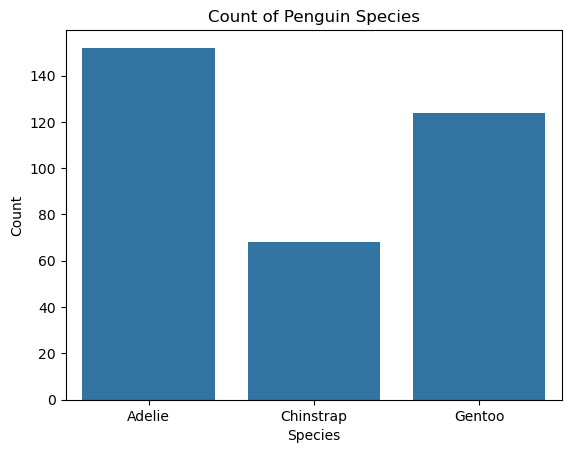

In [4]:
print("Penguin species:")
print(penguins["species"].unique())

sns.countplot(data=penguins, x="species")
plt.title("Count of Penguin Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Compare Body Mass of Different Species

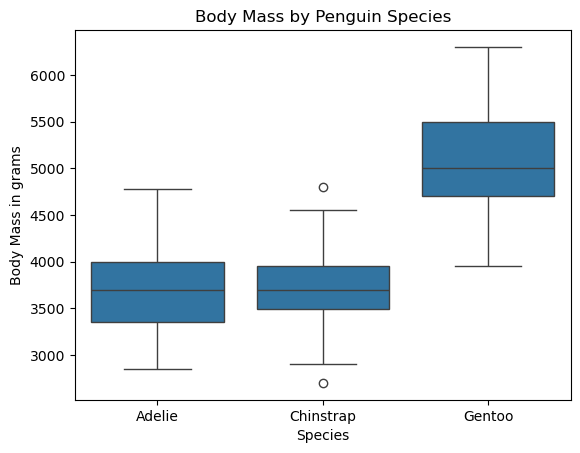

Average body mass by species:
species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


In [5]:
sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.title("Body Mass by Penguin Species")
plt.xlabel("Species")
plt.ylabel("Body Mass in grams")
plt.show()

print("Average body mass by species:")
print(penguins.groupby("species")["body_mass_g"].mean())

##
Gentoo penguins have the highest average body mass among the species.

#

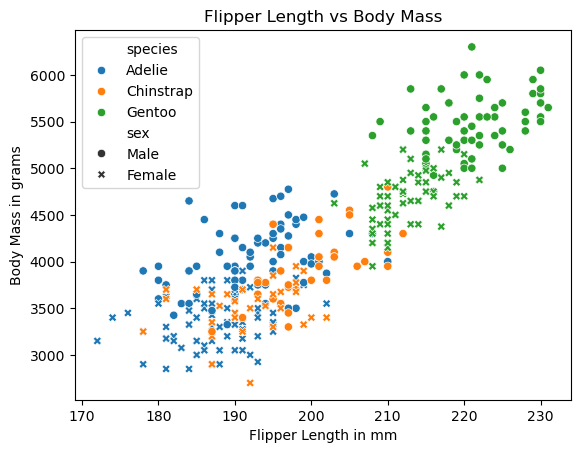

In [6]:
sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    style="sex"
)
plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length in mm")
plt.ylabel("Body Mass in grams")
plt.show()

## Observation
Penguins with longer flippers generally have higher body mass. Gentoo penguins are clearly separated from other species in this relationship.

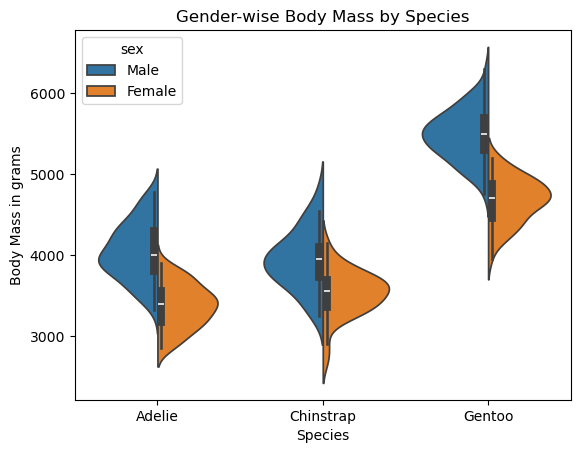

In [7]:
sns.violinplot(data=penguins, x="species", y="body_mass_g", hue="sex", split=True)
plt.title("Gender-wise Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass in grams")
plt.show()

## Observation
Male penguins are generally heavier than female penguins in most species.

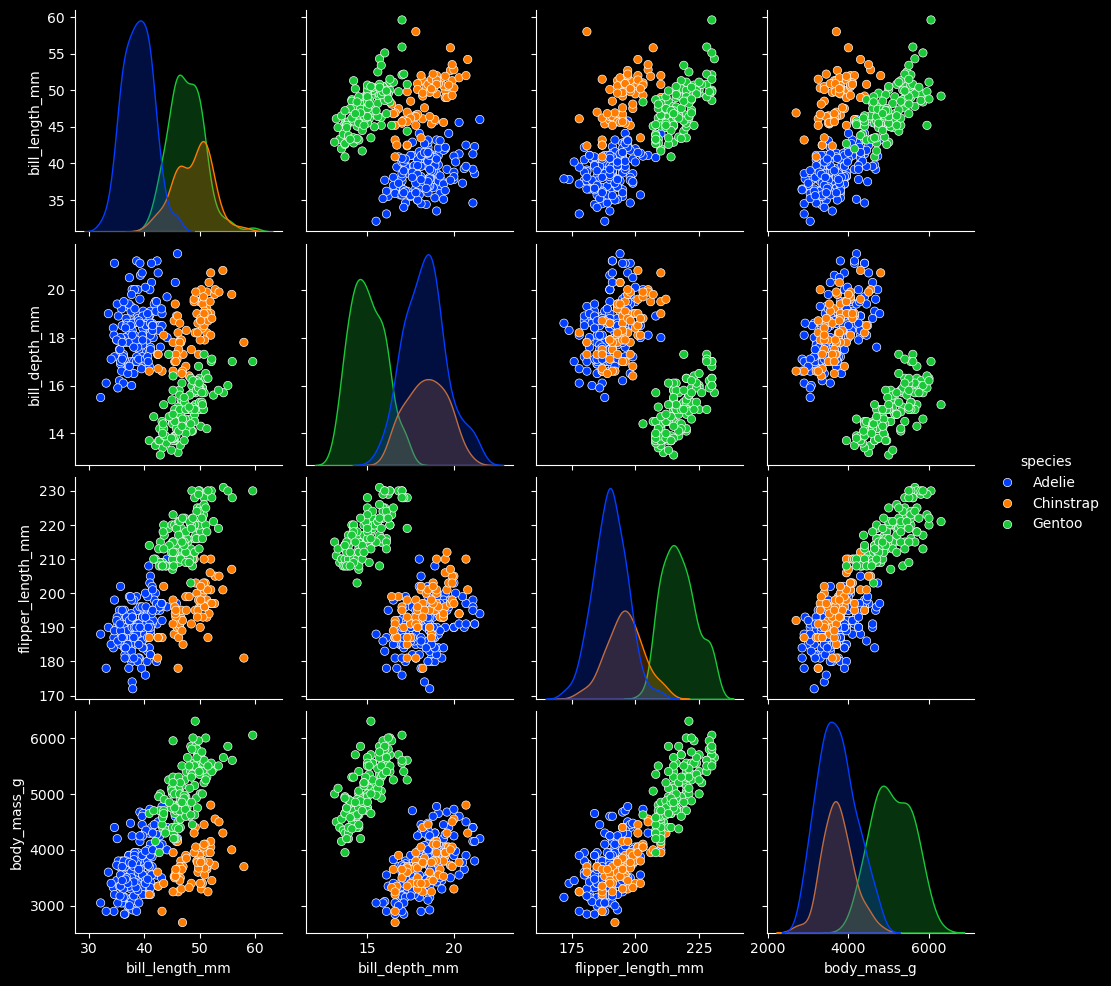

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

with plt.style.context("dark_background"):
    g = sns.pairplot(penguins.dropna(), hue="species", palette="bright")
    g.fig.patch.set_facecolor("black")
    for ax in g.axes.flat:
        if ax is not None:
            ax.set_facecolor("black")
    plt.show()

## Final Conclusion for Penguins Dataset
Body mass, flipper length, and bill measurements help separate penguin species. Gentoo penguins are usually heavier and have longer flippers. Pairplot is useful for seeing species separation visually.